# Reporting Layer — Environment, Docker/Spark/HDFS & MovieLens 25M Ingestion

Notebook này là lớp báo cáo bổ sung cho **notebook 1 + notebook 2**.  
Mục tiêu là đọc lại cấu hình Docker/Compose và dữ liệu raw đã ingest để sinh:

- Bảng kỹ thuật có thể đưa vào báo cáo.
- Hình PNG dùng cho slide.
- JSON/CSV manifest để tái sử dụng ở các reporting layer sau.
- Markdown summary cho chương môi trường thực nghiệm và ingest dữ liệu.


In [1]:
import os
import re
import json
import math
import textwrap
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    HAS_SEABORN = False

from IPython.display import display, Markdown, Image, HTML

PROJECT_ROOT = Path("/workspace")
# Có thể đổi slug này nếu bạn muốn output folder bám theo thứ tự notebook trong thư mục /notebooks.
REPORT_SLUG = "reporting_layer_1_2_environment_ingestion"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "reporting" / REPORT_SLUG
FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
METRIC_DIR = OUTPUT_ROOT / "metrics"
MD_DIR = OUTPUT_ROOT / "markdown"

for p in [OUTPUT_ROOT, FIG_DIR, TABLE_DIR, METRIC_DIR, MD_DIR]:
    p.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 180)

# Ép toàn bộ bảng HTML trong notebook căn trái để tránh lỗi mặc định pandas dồn header/cell về bên phải.
display(HTML("""
<style>
.dataframe thead th,
.dataframe tbody td,
.dataframe tbody th,
.jp-RenderedHTMLCommon table.dataframe thead th,
.jp-RenderedHTMLCommon table.dataframe tbody td {
    text-align: left !important;
    vertical-align: top !important;
    white-space: pre-wrap !important;
}
.dataframe tbody th {
    color: #444;
    font-weight: 600;
}
</style>
"""))

REPORT_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Reporting output root:", OUTPUT_ROOT)
print("Seaborn available:", HAS_SEABORN)


Reporting output root: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion
Seaborn available: True


In [2]:
DOCKERFILE_FALLBACK = 'FROM spark:3.5.8-python3\n\nUSER root\n\nENV DEBIAN_FRONTEND=noninteractive\n\nRUN apt-get update \\\n    && apt-get install -y --no-install-recommends \\\n        python3-pip \\\n        python3-dev \\\n        build-essential \\\n        curl \\\n        wget \\\n        git \\\n        procps \\\n        ca-certificates \\\n    && rm -rf /var/lib/apt/lists/*\n\nENV SPARK_HOME=/opt/spark\nENV PATH="${SPARK_HOME}/bin:${PATH}"\n\nENV PYSPARK_PYTHON=python3\nENV PYSPARK_DRIVER_PYTHON=python3\nENV TF_CPP_MIN_LOG_LEVEL=1\nENV TF_ENABLE_ONEDNN_OPTS=1\n\nRUN python3 -m pip install --upgrade pip setuptools wheel \\\n    && python3 -m pip install --no-cache-dir --ignore-installed blinker==1.9.0 \\\n    && python3 -m pip install --no-cache-dir \\\n        pyspark==3.5.8 \\\n        findspark \\\n        jupyterlab \\\n        notebook \\\n        pandas \\\n        numpy \\\n        scipy \\\n        matplotlib \\\n        seaborn \\\n        scikit-learn \\\n        pyarrow \\\n        tqdm \\\n        ipywidgets \\\n        streamlit \\\n        tensorflow==2.21.0\n\nWORKDIR /workspace\n\nEXPOSE 8888 4040 8501\n\nCMD ["bash", "-lc", "jupyter lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root --NotebookApp.token=\'\' --NotebookApp.password=\'\' --notebook-dir=/workspace"]\n'
COMPOSE_FALLBACK = '# Netflix-like Recommendation Big Data Lab\n# 5 containers: Hadoop NameNode, Hadoop DataNode, Spark Master, Spark Worker, Notebook + TensorFlow CPU\n# Resource budget: 6 CPU cores, 10GB RAM, 40GB disk.\n\nservices:\n  namenode:\n    image: apache/hadoop:3.4.3\n    container_name: netflix-namenode\n    hostname: namenode\n    restart: unless-stopped\n    user: "0:0"\n    command:\n      [\n        "bash",\n        "-lc",\n        "mkdir -p /hadoop/dfs/name /hadoop/tmp && chmod -R 755 /hadoop && if [ ! -f /hadoop/dfs/name/current/VERSION ]; then hdfs namenode -format -force -nonInteractive; fi && hdfs namenode"\n      ]\n    env_file:\n      - ./hadoop.env\n    environment:\n      ENSURE_NAMENODE_DIR: "/hadoop/dfs/name"\n    ports:\n      - "9870:9870"\n      - "8020:8020"\n    volumes:\n      - namenode_data:/hadoop/dfs/name\n    networks:\n      - netflix_bigdata_net\n    mem_limit: 768m\n    cpus: "0.50"\n    \n\n  datanode:\n    image: apache/hadoop:3.4.3\n    container_name: netflix-datanode\n    hostname: datanode\n    restart: unless-stopped\n    user: "0:0"\n    command:\n      [\n        "bash",\n        "-lc",\n        "mkdir -p /hadoop/dfs/data && chmod -R 755 /hadoop/dfs/data && hdfs datanode"\n      ]\n    env_file:\n      - ./hadoop.env\n    depends_on:\n      - namenode\n    ports:\n      - "9864:9864"\n    volumes:\n      - datanode_data:/hadoop/dfs/data\n    networks:\n      - netflix_bigdata_net\n    mem_limit: 1536m\n    cpus: "1.00"\n    \n\n  spark-master:\n    image: spark:3.5.8-python3\n    container_name: netflix-spark-master\n    hostname: spark-master\n    restart: "unless-stopped"\n    user: "0:0"\n    command: >\n      bash -lc "\n      mkdir -p /opt/spark/work &&\n      chmod -R 777 /opt/spark/work &&\n      /opt/spark/bin/spark-class\n      org.apache.spark.deploy.master.Master\n      --host spark-master\n      --port 7077\n      --webui-port 8080\n      "\n    depends_on:\n      - namenode\n      - datanode\n    ports:\n      - "8080:8080"   # Spark Master Web UI\n      - "7077:7077"   # Spark Master RPC\n    volumes:\n      - spark_master_work:/opt/spark/work\n    networks:\n      - netflix_bigdata_net\n    deploy:\n      resources:\n        limits:\n          cpus: "0.50"\n          memory: 768M\n\n  spark-worker:\n    image: spark:3.5.8-python3\n    container_name: netflix-spark-worker\n    hostname: spark-worker\n    restart: unless-stopped\n    user: "0:0"\n    environment:\n      PYSPARK_PYTHON: python3\n      PYSPARK_DRIVER_PYTHON: python3\n    command: >\n      bash -lc "\n      mkdir -p /opt/spark/work &&\n      chmod -R 777 /opt/spark/work &&\n      /opt/spark/bin/spark-class\n      org.apache.spark.deploy.worker.Worker\n      spark://spark-master:7077\n      --webui-port 8081\n      --cores 2\n      --memory 3g\n      --work-dir /opt/spark/work\n      "\n    depends_on:\n      - spark-master\n    ports:\n      - "8081:8081"   # Spark Worker Web UI\n    volumes:\n      - spark_worker_work:/opt/spark/work\n      - ./data:/workspace/data\n      - ./outputs:/workspace/outputs\n    networks:\n      - netflix_bigdata_net\n    deploy:\n      resources:\n        limits:\n          cpus: "2.50"\n          memory: 4G\n    \n\n  notebook:\n    build:\n      context: .\n      dockerfile: Dockerfile.notebook\n    container_name: netflix-notebook-tf-cpu\n    hostname: notebook\n    restart: unless-stopped\n    environment:\n      JUPYTER_ENABLE_LAB: "yes"\n      SPARK_MASTER_URL: spark://spark-master:7077\n      HDFS_URI: hdfs://namenode:8020\n      PYSPARK_PYTHON: python3\n      PYSPARK_DRIVER_PYTHON: python3\n      TF_CPP_MIN_LOG_LEVEL: "1"\n      TF_ENABLE_ONEDNN_OPTS: "1"\n    depends_on:\n      - namenode\n      - datanode\n      - spark-master\n      - spark-worker\n    ports:\n      - "8888:8888"   # JupyterLab\n      - "4040:4040"   # Spark Application UI\n      - "8501:8501"   # Optional Streamlit demo if used later\n    volumes:\n      - ./data:/workspace/data\n      - ./notebooks:/workspace/notebooks\n      - ./src:/workspace/src\n      - ./outputs:/workspace/outputs\n      - ./models:/workspace/models\n    networks:\n      - netflix_bigdata_net\n    mem_limit: 3g\n    cpus: "1.50"\n\nnetworks:\n  netflix_bigdata_net:\n    driver: bridge\n\nvolumes:\n  namenode_data:\n  datanode_data:\n  spark_master_work:\n  spark_worker_work:\n'

def read_first_existing(candidates, fallback_text=None):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path, path.read_text(encoding="utf-8", errors="replace")
    return None, fallback_text or ""

dockerfile_path, dockerfile_text = read_first_existing(
    [
        PROJECT_ROOT / "Dockerfile.notebook",
        PROJECT_ROOT / "dockerfile.notebook",
        PROJECT_ROOT / "notebooks" / "Dockerfile.notebook",
        Path.cwd() / "Dockerfile.notebook",
        Path.cwd().parent / "Dockerfile.notebook",
    ],
    DOCKERFILE_FALLBACK,
)

compose_path, compose_text = read_first_existing(
    [
        PROJECT_ROOT / "docker-compose.yml",
        PROJECT_ROOT / "compose.yml",
        PROJECT_ROOT / "docker-compose.yaml",
        PROJECT_ROOT / "notebooks" / "docker-compose.yml",
        Path.cwd() / "docker-compose.yml",
        Path.cwd().parent / "docker-compose.yml",
    ],
    COMPOSE_FALLBACK,
)

print("Dockerfile source:", dockerfile_path or "embedded fallback from uploaded Dockerfile.notebook")
print("Compose source:", compose_path or "embedded fallback from uploaded docker-compose.yml")
print("Dockerfile lines:", len(dockerfile_text.splitlines()))
print("Compose lines:", len(compose_text.splitlines()))

Dockerfile source: embedded fallback from uploaded Dockerfile.notebook
Compose source: embedded fallback from uploaded docker-compose.yml
Dockerfile lines: 50
Compose lines: 172


In [3]:
def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def save_df(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False, encoding="utf-8")
    return path


def _style_dataframe_left(df):
    """Trả về pandas Styler căn trái cho cả header và body."""
    styler = (
        df.style
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("vertical-align", "top")]},
            {"selector": "td", "props": [("text-align", "left"), ("vertical-align", "top"), ("white-space", "pre-wrap")]},
        ])
        .set_properties(**{"text-align": "left", "vertical-align": "top", "white-space": "pre-wrap"})
    )
    try:
        styler = styler.hide(axis="index")
    except Exception:
        pass
    return styler


def display_df(df, title=None, max_rows=80):
    """Display DataFrame với alignment ổn định, dùng chung cho toàn bộ reporting layer."""
    if title:
        display(Markdown(f"### {title}"))
    if df is None or len(df) == 0:
        display(Markdown("_No rows to display._"))
        return
    show_df = df.head(max_rows).copy()
    display(_style_dataframe_left(show_df))


def _wrap_cell(value, width=24):
    text = "" if pd.isna(value) else str(value)
    # Giữ path/log dễ đọc hơn bằng cách cho phép xuống dòng ở dấu / và dấu ,.
    text = text.replace("/", "/\u200b").replace(", ", ",\n")
    return textwrap.fill(text, width=width, break_long_words=False, break_on_hyphens=False)


def save_table_image(df, filename, title=None, max_rows=30, font_size=9, scale_y=1.28, wrap_width=26):
    """Lưu DataFrame thành PNG căn trái, có wrap text, phù hợp đưa vào slide."""
    out = FIG_DIR / filename
    if df is None or df.empty:
        fig, ax = plt.subplots(figsize=(8, 2.4))
        ax.axis("off")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=13)
        if title:
            ax.set_title(title, fontsize=14, weight="bold", pad=12)
        fig.savefig(out, dpi=180, bbox_inches="tight")
        plt.close(fig)
        return out

    show_df = df.head(max_rows).copy()
    wrapped = show_df.copy()
    for col in wrapped.columns:
        col_width = wrap_width
        if col in {"path", "hdfs_raw_path", "role_in_project", "evidence", "reporting_role", "command", "value"}:
            col_width = max(wrap_width, 34)
        wrapped[col] = wrapped[col].map(lambda x: _wrap_cell(x, width=col_width))

    row_line_counts = []
    for _, row in wrapped.iterrows():
        row_line_counts.append(max(str(v).count("\n") + 1 for v in row.values))

    fig_w = max(10, min(26, 1.75 * len(wrapped.columns) + 7))
    fig_h = max(2.8, 0.42 * sum(row_line_counts) + 1.8)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=15, weight="bold", pad=16)

    table_bbox = [0.01, 0.02, 0.98, 0.86 if title else 0.94]
    table = ax.table(
        cellText=wrapped.astype(str).values,
        colLabels=list(wrapped.columns),
        cellLoc="left",
        colLoc="left",
        bbox=table_bbox,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.get_text().set_ha("left")
        cell.get_text().set_va("center")
        cell.PAD = 0.045
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_height(cell.get_height() * 1.18)
        elif row - 1 < len(row_line_counts):
            cell.set_height(cell.get_height() * max(1.0, 0.88 * row_line_counts[row - 1]))

    fig.tight_layout()
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return out


def parse_memory_to_gb(value):
    if value is None:
        return np.nan
    s = str(value).strip().lower()
    m = re.match(r"([0-9.]+)\s*([kmgt]?i?b?|[kmgt])?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = (m.group(2) or "b").lower()
    if unit in ["g", "gb", "gib"]:
        return num
    if unit in ["m", "mb", "mib"]:
        return num / 1024
    if unit in ["k", "kb", "kib"]:
        return num / (1024 ** 2)
    return num / (1024 ** 3)


def parse_cpu_to_float(value):
    if value is None:
        return np.nan
    try:
        return float(str(value).replace('"', '').strip())
    except Exception:
        return np.nan


def annotate_bars(ax, fmt="{:.0f}", rotation=0):
    for p in ax.patches:
        value = p.get_height()
        if value is None or (isinstance(value, float) and math.isnan(value)):
            continue
        ax.annotate(
            fmt.format(value),
            (p.get_x() + p.get_width() / 2, value),
            ha="center",
            va="bottom",
            fontsize=10,
            rotation=rotation,
            xytext=(0, 4),
            textcoords="offset points",
        )


def safe_int(x):
    try:
        return int(x)
    except Exception:
        return None


In [4]:
base_image = None
m = re.search(r"^FROM\s+([^\s]+)", dockerfile_text, flags=re.MULTILINE)
if m:
    base_image = m.group(1)

env_rows = []
for key, value in re.findall(r"^ENV\s+([A-Za-z_][A-Za-z0-9_]*)=(.+)$", dockerfile_text, flags=re.MULTILINE):
    env_rows.append({"key": key, "value": value.strip().strip('"')})

docker_env_df = pd.DataFrame(env_rows)

exposed_ports = []
for line in dockerfile_text.splitlines():
    line = line.strip()
    if line.startswith("EXPOSE"):
        exposed_ports.extend(line.replace("EXPOSE", "").strip().split())

docker_expose_df = pd.DataFrame([{"port": p, "purpose": {"8888": "JupyterLab", "4040": "Spark Application UI", "8501": "Optional Streamlit demo"}.get(p, "Runtime service")} for p in exposed_ports])

# Trích package được pip install trong Dockerfile.
known_packages = [
    "pyspark", "findspark", "jupyterlab", "notebook", "pandas", "numpy", "scipy",
    "matplotlib", "seaborn", "scikit-learn", "pyarrow", "tqdm", "ipywidgets",
    "streamlit", "tensorflow", "blinker"
]
package_rows = []
for pkg in known_packages:
    pattern = rf"{re.escape(pkg)}(?:==([0-9A-Za-z\-.]+))?"
    match = re.search(pattern, dockerfile_text)
    if match:
        package_rows.append({
            "package": pkg,
            "version_pin": match.group(1) or "not pinned",
            "reporting_role": {
                "pyspark": "Spark jobs, HDFS parquet checks, ingestion verification",
                "tensorflow": "Hybrid NCF training/runtime environment",
                "pandas": "Tabular reporting and CSV exports",
                "numpy": "Numeric reporting utilities",
                "matplotlib": "Static figures for report and slides",
                "seaborn": "High-level statistical visualization",
                "pyarrow": "Parquet interoperability",
                "jupyterlab": "Notebook execution interface",
                "streamlit": "Optional demo UI",
            }.get(pkg, "Supporting library")
        })

docker_packages_df = pd.DataFrame(package_rows).sort_values("package").reset_index(drop=True)

runtime_stack_df = pd.DataFrame([
    {"component": "Base image", "value": base_image or "unknown", "evidence": "Dockerfile FROM"},
    {"component": "Spark runtime", "value": "Spark 3.5.8 Python image", "evidence": "spark:3.5.8-python3 + pyspark==3.5.8"},
    {"component": "TensorFlow", "value": "2.21.0", "evidence": "Dockerfile pip install tensorflow==2.21.0"},
    {"component": "Visualization", "value": "matplotlib + seaborn", "evidence": "Dockerfile pip install"},
    {"component": "Notebook UI", "value": "JupyterLab on port 8888", "evidence": "Dockerfile CMD + EXPOSE 8888"},
    {"component": "Spark Application UI", "value": "port 4040", "evidence": "Dockerfile EXPOSE 4040"},
    {"component": "Optional demo UI", "value": "Streamlit on port 8501", "evidence": "Dockerfile EXPOSE 8501"},
])

display_df(runtime_stack_df, "Dockerfile runtime stack")
display_df(docker_packages_df, "Python package inventory from Dockerfile")

### Dockerfile runtime stack

component,value,evidence
Base image,spark:3.5.8-python3,Dockerfile FROM
Spark runtime,Spark 3.5.8 Python image,spark:3.5.8-python3 + pyspark==3.5.8
TensorFlow,2.21.0,Dockerfile pip install tensorflow==2.21.0
Visualization,matplotlib + seaborn,Dockerfile pip install
Notebook UI,JupyterLab on port 8888,Dockerfile CMD + EXPOSE 8888
Spark Application UI,port 4040,Dockerfile EXPOSE 4040
Optional demo UI,Streamlit on port 8501,Dockerfile EXPOSE 8501


### Python package inventory from Dockerfile

package,version_pin,reporting_role
blinker,1.9.0,Supporting library
findspark,not pinned,Supporting library
ipywidgets,not pinned,Supporting library
jupyterlab,not pinned,Notebook execution interface
matplotlib,not pinned,Static figures for report and slides
notebook,not pinned,Supporting library
numpy,not pinned,Numeric reporting utilities
pandas,not pinned,Tabular reporting and CSV exports
pyarrow,not pinned,Parquet interoperability
pyspark,3.5.8,"Spark jobs, HDFS parquet checks, ingestion verification"


In [5]:
try:
    import yaml
    compose_obj = yaml.safe_load(compose_text)
except Exception as e:
    compose_obj = None
    print("PyYAML unavailable or compose parse failed; fallback parser will be used.", e)

service_role_map = {
    "namenode": "HDFS namespace manager; quản lý metadata và Web UI HDFS.",
    "datanode": "HDFS storage worker; lưu block dữ liệu thực tế.",
    "spark-master": "Spark cluster master; nhận application và điều phối worker.",
    "spark-worker": "Spark executor worker; xử lý job Spark phân tán.",
    "notebook": "JupyterLab + TensorFlow CPU; driver container để chạy notebook và reporting.",
}

port_purpose_map = {
    "9870": "HDFS NameNode Web UI",
    "8020": "HDFS RPC / fs.defaultFS",
    "9864": "HDFS DataNode Web UI",
    "8080": "Spark Master Web UI",
    "7077": "Spark Master RPC",
    "8081": "Spark Worker Web UI",
    "8888": "JupyterLab",
    "4040": "Spark Application UI",
    "8501": "Optional Streamlit demo",
}

service_rows = []
port_rows = []
volume_rows = []
dependency_rows = []
env_rows = []

if compose_obj and "services" in compose_obj:
    for svc_name, svc in compose_obj.get("services", {}).items():
        container_name = svc.get("container_name", svc_name)
        image = svc.get("image")
        build = svc.get("build")
        build_ref = None
        if isinstance(build, dict):
            build_ref = build.get("dockerfile") or str(build)
        elif build:
            build_ref = str(build)
        cpus = svc.get("cpus")
        mem = svc.get("mem_limit")
        deploy_limits = (((svc.get("deploy") or {}).get("resources") or {}).get("limits") or {})
        if cpus is None:
            cpus = deploy_limits.get("cpus")
        if mem is None:
            mem = deploy_limits.get("memory")
        service_rows.append({
            "service": svc_name,
            "container_name": container_name,
            "image_or_build": image or build_ref or "custom build",
            "role": service_role_map.get(svc_name, "Big Data service"),
            "cpu_limit": cpus,
            "cpu_limit_num": parse_cpu_to_float(cpus),
            "memory_limit": mem,
            "memory_limit_gb": parse_memory_to_gb(mem),
            "restart": svc.get("restart", "not specified"),
        })
        for port in svc.get("ports", []) or []:
            p = str(port).replace('"', '')
            if ":" in p:
                host, container = p.split(":", 1)
            else:
                host, container = p, p
            port_rows.append({
                "service": svc_name,
                "host_port": host,
                "container_port": container,
                "purpose": port_purpose_map.get(host) or port_purpose_map.get(container) or "service port",
            })
        vols = svc.get("volumes", []) or []
        for vol in vols:
            v = str(vol)
            parts = v.split(":")
            volume_rows.append({
                "service": svc_name,
                "source": parts[0] if len(parts) >= 1 else v,
                "target": parts[1] if len(parts) >= 2 else "",
                "role": "Persistent data / mounted project folder",
            })
        deps = svc.get("depends_on", []) or []
        if isinstance(deps, dict):
            deps = list(deps.keys())
        for dep in deps:
            dependency_rows.append({"service": svc_name, "depends_on": dep})
        environment = svc.get("environment", {}) or {}
        if isinstance(environment, dict):
            for k, v in environment.items():
                env_rows.append({"service": svc_name, "key": k, "value": v})
        elif isinstance(environment, list):
            for item in environment:
                if "=" in str(item):
                    k, v = str(item).split("=", 1)
                    env_rows.append({"service": svc_name, "key": k, "value": v})
else:
    # Fallback rất hẹp cho trường hợp không có yaml parser.
    service_names = re.findall(r"^\s{2}([A-Za-z0-9_-]+):\s*$", compose_text, flags=re.MULTILINE)
    for svc_name in service_names:
        service_rows.append({
            "service": svc_name,
            "container_name": svc_name,
            "image_or_build": "parse manually from compose",
            "role": service_role_map.get(svc_name, "Big Data service"),
            "cpu_limit": None,
            "cpu_limit_num": np.nan,
            "memory_limit": None,
            "memory_limit_gb": np.nan,
            "restart": "unknown",
        })

services_df = pd.DataFrame(service_rows)
ports_df = pd.DataFrame(port_rows)
volumes_df = pd.DataFrame(volume_rows)
dependencies_df = pd.DataFrame(dependency_rows)
compose_env_df = pd.DataFrame(env_rows)

# Chuẩn hóa thứ tự service theo kiến trúc pipeline.
service_order = ["namenode", "datanode", "spark-master", "spark-worker", "notebook"]
if not services_df.empty:
    services_df["service_order"] = services_df["service"].map({s:i for i,s in enumerate(service_order)}).fillna(99)
    services_df = services_df.sort_values("service_order").drop(columns=["service_order"]).reset_index(drop=True)

print("Number of services:", len(services_df))
display_df(services_df, "Docker Compose services")
display_df(ports_df, "Exposed host ports")

Number of services: 5


### Docker Compose services

service,container_name,image_or_build,role,cpu_limit,cpu_limit_num,memory_limit,memory_limit_gb,restart
namenode,netflix-namenode,apache/hadoop:3.4.3,HDFS namespace manager; quản lý metadata và Web UI HDFS.,0.50,0.500000,768m,0.750000,unless-stopped
datanode,netflix-datanode,apache/hadoop:3.4.3,HDFS storage worker; lưu block dữ liệu thực tế.,1.00,1.000000,1536m,1.500000,unless-stopped
spark-master,netflix-spark-master,spark:3.5.8-python3,Spark cluster master; nhận application và điều phối worker.,0.50,0.500000,768M,0.750000,unless-stopped
spark-worker,netflix-spark-worker,spark:3.5.8-python3,Spark executor worker; xử lý job Spark phân tán.,2.50,2.500000,4G,4.000000,unless-stopped
notebook,netflix-notebook-tf-cpu,Dockerfile.notebook,JupyterLab + TensorFlow CPU; driver container để chạy notebook và reporting.,1.50,1.500000,3g,3.000000,unless-stopped


### Exposed host ports

service,host_port,container_port,purpose
namenode,9870,9870,HDFS NameNode Web UI
namenode,8020,8020,HDFS RPC / fs.defaultFS
datanode,9864,9864,HDFS DataNode Web UI
spark-master,8080,8080,Spark Master Web UI
spark-master,7077,7077,Spark Master RPC
spark-worker,8081,8081,Spark Worker Web UI
notebook,8888,8888,JupyterLab
notebook,4040,4040,Spark Application UI
notebook,8501,8501,Optional Streamlit demo


In [6]:
spark_check_config_df = pd.DataFrame([
    {"config_key": "spark.app.name", "value": "1_Check_Environment", "meaning": "Tên job kiểm tra môi trường"},
    {"config_key": "spark.master", "value": "spark://spark-master:7077", "meaning": "Kết nối notebook driver tới Spark Master trong Docker network"},
    {"config_key": "spark.hadoop.fs.defaultFS", "value": "hdfs://namenode:8020", "meaning": "HDFS NameNode làm filesystem mặc định"},
    {"config_key": "spark.driver.host", "value": "notebook", "meaning": "Worker gọi ngược lại driver qua hostname notebook"},
    {"config_key": "spark.driver.bindAddress", "value": "0.0.0.0", "meaning": "Driver bind mọi interface trong container"},
    {"config_key": "spark.driver.memory", "value": "1g", "meaning": "Bộ nhớ driver cho bước kiểm tra nhẹ"},
    {"config_key": "spark.executor.memory", "value": "2g", "meaning": "Bộ nhớ executor khi kiểm tra Spark"},
    {"config_key": "spark.executor.cores", "value": "1", "meaning": "Số core executor cho bước kiểm tra"},
    {"config_key": "spark.cores.max", "value": "2", "meaning": "Giới hạn tổng core Spark dùng trong bước kiểm tra"},
    {"config_key": "spark.sql.shuffle.partitions", "value": "16", "meaning": "Giảm số partition shuffle để phù hợp máy cá nhân"},
    {"config_key": "spark.ui.port", "value": "4040", "meaning": "Spark Application UI"},
])

environment_validation_df = pd.DataFrame([
    {"check": "Python runtime", "expected_result": "sys.version được in ra", "report_meaning": "Xác nhận notebook container có Python để chạy PySpark/TensorFlow"},
    {"check": "TensorFlow runtime", "expected_result": "tf.__version__ và CPU device được in ra", "report_meaning": "Xác nhận môi trường có TensorFlow CPU cho Hybrid NCF"},
    {"check": "SparkSession", "expected_result": "Spark version + spark://spark-master:7077", "report_meaning": "Xác nhận notebook kết nối được Spark cluster"},
    {"check": "Spark job smoke test", "expected_result": "spark.range(10).count() = 10", "report_meaning": "Xác nhận job Spark chạy thành công trên cluster"},
    {"check": "HDFS listStatus", "expected_result": "liệt kê được hdfs://namenode:8020/", "report_meaning": "Xác nhận Spark truy cập được HDFS"},
])

display(Markdown("### Notebook 1 — environment validation checklist"))
display(environment_validation_df)
display(Markdown("### Notebook 1 — Spark configuration reconstructed from executed notebook"))
display(spark_check_config_df)

### Notebook 1 — environment validation checklist

,check,expected_result,report_meaning
0,Python runtime,sys.version được in ra,Xác nhận notebook container có Python để chạy PySpark/TensorFlow
1,TensorFlow runtime,tf.__version__ và CPU device được in ra,Xác nhận môi trường có TensorFlow CPU cho Hybrid NCF
2,SparkSession,Spark version + spark://spark-master:7077,Xác nhận notebook kết nối được Spark cluster
3,Spark job smoke test,spark.range(10).count() = 10,Xác nhận job Spark chạy thành công trên cluster
4,HDFS listStatus,liệt kê được hdfs://namenode:8020/,Xác nhận Spark truy cập được HDFS


### Notebook 1 — Spark configuration reconstructed from executed notebook

,config_key,value,meaning
0,spark.app.name,1_Check_Environment,Tên job kiểm tra môi trường
1,spark.master,spark://spark-master:7077,Kết nối notebook driver tới Spark Master trong Docker network
2,spark.hadoop.fs.defaultFS,hdfs://namenode:8020,HDFS NameNode làm filesystem mặc định
3,spark.driver.host,notebook,Worker gọi ngược lại driver qua hostname notebook
4,spark.driver.bindAddress,0.0.0.0,Driver bind mọi interface trong container
5,spark.driver.memory,1g,Bộ nhớ driver cho bước kiểm tra nhẹ
6,spark.executor.memory,2g,Bộ nhớ executor khi kiểm tra Spark
7,spark.executor.cores,1,Số core executor cho bước kiểm tra
8,spark.cores.max,2,Giới hạn tổng core Spark dùng trong bước kiểm tra
9,spark.sql.shuffle.partitions,16,Giảm số partition shuffle để phù hợp máy cá nhân


In [7]:
schema_rows = [
    {"dataset": "ratings", "column": "userId", "type": "IntegerType", "business_meaning": "ID người dùng"},
    {"dataset": "ratings", "column": "movieId", "type": "IntegerType", "business_meaning": "ID phim"},
    {"dataset": "ratings", "column": "rating", "type": "FloatType", "business_meaning": "Điểm đánh giá 0.5–5.0"},
    {"dataset": "ratings", "column": "timestamp", "type": "LongType", "business_meaning": "Thời điểm rating dạng Unix timestamp"},
    {"dataset": "movies", "column": "movieId", "type": "IntegerType", "business_meaning": "ID phim"},
    {"dataset": "movies", "column": "title", "type": "StringType", "business_meaning": "Tên phim, thường kèm năm phát hành"},
    {"dataset": "movies", "column": "genres", "type": "StringType", "business_meaning": "Danh sách thể loại phim phân tách bằng dấu '|'"},
    {"dataset": "tags", "column": "userId", "type": "IntegerType", "business_meaning": "ID người dùng gắn tag"},
    {"dataset": "tags", "column": "movieId", "type": "IntegerType", "business_meaning": "ID phim được gắn tag"},
    {"dataset": "tags", "column": "tag", "type": "StringType", "business_meaning": "Nhãn mô tả do người dùng nhập"},
    {"dataset": "tags", "column": "timestamp", "type": "LongType", "business_meaning": "Thời điểm gắn tag"},
    {"dataset": "links", "column": "movieId", "type": "IntegerType", "business_meaning": "ID phim nội bộ MovieLens"},
    {"dataset": "links", "column": "imdbId", "type": "StringType", "business_meaning": "ID mapping sang IMDb"},
    {"dataset": "links", "column": "tmdbId", "type": "StringType", "business_meaning": "ID mapping sang TMDB"},
    {"dataset": "genome_scores", "column": "movieId", "type": "IntegerType", "business_meaning": "ID phim có vector genome"},
    {"dataset": "genome_scores", "column": "tagId", "type": "IntegerType", "business_meaning": "ID genome tag"},
    {"dataset": "genome_scores", "column": "relevance", "type": "FloatType", "business_meaning": "Mức độ liên quan giữa phim và genome tag"},
    {"dataset": "genome_tags", "column": "tagId", "type": "IntegerType", "business_meaning": "ID genome tag"},
    {"dataset": "genome_tags", "column": "tag", "type": "StringType", "business_meaning": "Tên genome tag"},
]
ingest_schema_df = pd.DataFrame(schema_rows)

dataset_role_df = pd.DataFrame([
    {"dataset": "ratings", "file": "ratings.csv", "hdfs_raw_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m/ratings", "role_in_project": "Nguồn tương tác user–movie chính; dùng cho EDA, long-term users, ALS, labeled interactions"},
    {"dataset": "movies", "file": "movies.csv", "hdfs_raw_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m/movies", "role_in_project": "Metadata phim; dùng nối title/genres và giải thích recommendation"},
    {"dataset": "tags", "file": "tags.csv", "hdfs_raw_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m/tags", "role_in_project": "Tag do user nhập; phục vụ EDA về ngữ nghĩa người dùng"},
    {"dataset": "links", "file": "links.csv", "hdfs_raw_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m/links", "role_in_project": "Mapping sang IMDb/TMDB; hữu ích khi mở rộng metadata"},
    {"dataset": "genome_scores", "file": "genome-scores.csv", "hdfs_raw_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_scores", "role_in_project": "Feature nội dung phim; dùng cho EDA genome và Hybrid NCF"},
    {"dataset": "genome_tags", "file": "genome-tags.csv", "hdfs_raw_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_tags", "role_in_project": "Từ điển tag genome; giúp giải thích ý nghĩa feature genome"},
])

hdfs_zone_df = pd.DataFrame([
    {"zone": "raw/ml-25m", "hdfs_path": "hdfs://namenode:8020/netflix-recsys/raw/ml-25m", "purpose": "Lưu dữ liệu MovieLens 25M dạng parquet sau ingest"},
    {"zone": "bronze", "hdfs_path": "hdfs://namenode:8020/netflix-recsys/bronze", "purpose": "Vùng dự phòng cho dữ liệu gần raw nếu cần mở rộng pipeline"},
    {"zone": "silver", "hdfs_path": "hdfs://namenode:8020/netflix-recsys/silver", "purpose": "Vùng dữ liệu đã làm sạch/chuyển đổi trung gian"},
    {"zone": "gold", "hdfs_path": "hdfs://namenode:8020/netflix-recsys/gold", "purpose": "Vùng dữ liệu phục vụ modeling và reporting"},
    {"zone": "models", "hdfs_path": "hdfs://namenode:8020/netflix-recsys/models", "purpose": "Vùng lưu model Spark nếu cần"},
    {"zone": "outputs", "hdfs_path": "hdfs://namenode:8020/netflix-recsys/outputs", "purpose": "Vùng lưu predictions, recommendations và output cuối"},
])

display(Markdown("### Notebook 2 — explicit ingestion schema"))
display(ingest_schema_df)
display(Markdown("### Notebook 2 — dataset role and HDFS raw path"))
display(dataset_role_df)

### Notebook 2 — explicit ingestion schema

,dataset,column,type,business_meaning
0,ratings,userId,IntegerType,ID người dùng
1,ratings,movieId,IntegerType,ID phim
2,ratings,rating,FloatType,Điểm đánh giá 0.5–5.0
3,ratings,timestamp,LongType,Thời điểm rating dạng Unix timestamp
4,movies,movieId,IntegerType,ID phim
5,movies,title,StringType,"Tên phim, thường kèm năm phát hành"
6,movies,genres,StringType,Danh sách thể loại phim phân tách bằng dấu |
7,tags,userId,IntegerType,ID người dùng gắn tag
8,tags,movieId,IntegerType,ID phim được gắn tag
9,tags,tag,StringType,Nhãn mô tả do người dùng nhập


### Notebook 2 — dataset role and HDFS raw path

,dataset,file,hdfs_raw_path,role_in_project
0,ratings,ratings.csv,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/ratings,"Nguồn tương tác user–movie chính; dùng cho EDA, long-term users, ALS, labeled interactions"
1,movies,movies.csv,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/movies,Metadata phim; dùng nối title/genres và giải thích recommendation
2,tags,tags.csv,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/tags,Tag do user nhập; phục vụ EDA về ngữ nghĩa người dùng
3,links,links.csv,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/links,Mapping sang IMDb/TMDB; hữu ích khi mở rộng metadata
4,genome_scores,genome-scores.csv,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_scores,Feature nội dung phim; dùng cho EDA genome và Hybrid NCF
5,genome_tags,genome-tags.csv,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_tags,Từ điển tag genome; giúp giải thích ý nghĩa feature genome


In [8]:
RUN_SPARK_HDFS_CHECKS = os.environ.get("RUN_SPARK_HDFS_CHECKS", "auto").lower()
if RUN_SPARK_HDFS_CHECKS == "auto":
    # Chỉ tự thử Spark/HDFS khi notebook đang chạy trong compose network có hostname namenode/spark-master.
    import socket
    try:
        socket.gethostbyname("namenode")
        socket.gethostbyname("spark-master")
        RUN_SPARK_HDFS_CHECKS = True
    except Exception:
        RUN_SPARK_HDFS_CHECKS = False
else:
    RUN_SPARK_HDFS_CHECKS = RUN_SPARK_HDFS_CHECKS in {"1", "true", "yes", "y"}

EXPECTED_COUNTS = {
    "ratings": {"rows": 25_000_095, "columns": 4},
    "movies": {"rows": 62_423, "columns": 3},
    "tags": {"rows": 1_093_360, "columns": 4},
    "links": {"rows": 62_423, "columns": 3},
    "genome_scores": {"rows": 15_584_448, "columns": 3},
    "genome_tags": {"rows": 1_128, "columns": 2},
}

HDFS_BASE = "hdfs://namenode:8020/netflix-recsys"
HDFS_RAW = f"{HDFS_BASE}/raw/ml-25m"

hdfs_check_status = {
    "attempted": RUN_SPARK_HDFS_CHECKS,
    "success": False,
    "error": None,
    "source_used": "fallback_expected_movielens_25m",
}

ingest_count_rows = []

if RUN_SPARK_HDFS_CHECKS:
    try:
        from pyspark.sql import SparkSession
        spark = (
            SparkSession.builder
            .appName("1_2_Reporting_Layer_HDFS_Verification")
            .master(os.environ.get("SPARK_MASTER_URL", "spark://spark-master:7077"))
            .config("spark.hadoop.fs.defaultFS", os.environ.get("HDFS_URI", "hdfs://namenode:8020"))
            .config("spark.driver.host", "notebook")
            .config("spark.driver.bindAddress", "0.0.0.0")
            .config("spark.driver.memory", "1g")
            .config("spark.executor.memory", "1g")
            .config("spark.executor.cores", "1")
            .config("spark.cores.max", "1")
            .config("spark.executor.instances", "1")
            .config("spark.sql.shuffle.partitions", "16")
            .getOrCreate()
        )
        spark.sparkContext.setLogLevel("WARN")
        for dataset in EXPECTED_COUNTS:
            path = f"{HDFS_RAW}/{dataset}"
            df = spark.read.parquet(path)
            ingest_count_rows.append({
                "dataset": dataset,
                "rows": df.count(),
                "columns": len(df.columns),
                "hdfs_raw_path": path,
                "count_source": "hdfs_parquet_count",
            })
        hdfs_check_status.update({"success": True, "source_used": "hdfs_parquet_count"})
    except Exception as e:
        hdfs_check_status.update({"success": False, "error": repr(e), "source_used": "fallback_expected_movielens_25m"})
        ingest_count_rows = []

if not ingest_count_rows:
    for dataset, meta in EXPECTED_COUNTS.items():
        ingest_count_rows.append({
            "dataset": dataset,
            "rows": meta["rows"],
            "columns": meta["columns"],
            "hdfs_raw_path": f"{HDFS_RAW}/{dataset}",
            "count_source": hdfs_check_status["source_used"],
        })

ingest_counts_df = pd.DataFrame(ingest_count_rows)
ingest_counts_df = ingest_counts_df.merge(dataset_role_df[["dataset", "file", "role_in_project"]], on="dataset", how="left")
ingest_counts_df["rows_million"] = ingest_counts_df["rows"] / 1_000_000
ingest_counts_df["dataset_group"] = np.where(ingest_counts_df["dataset"].str.contains("genome"), "Genome content features", "Core MovieLens tables")

total_rows = int(ingest_counts_df["rows"].sum())
genome_rows = int(ingest_counts_df.loc[ingest_counts_df["dataset_group"] == "Genome content features", "rows"].sum())
core_rows = total_rows - genome_rows

display_df(ingest_counts_df, "HDFS raw parquet verification / fallback ingest counts")
print("HDFS check status:", hdfs_check_status)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/07 04:51:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/07 04:51:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
                                                                                

### HDFS raw parquet verification / fallback ingest counts

dataset,rows,columns,hdfs_raw_path,count_source,file,role_in_project,rows_million,dataset_group
ratings,25000095,4,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/ratings,hdfs_parquet_count,ratings.csv,"Nguồn tương tác user–movie chính; dùng cho EDA, long-term users, ALS, labeled interactions",25.000095,Core MovieLens tables
movies,62423,3,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/movies,hdfs_parquet_count,movies.csv,Metadata phim; dùng nối title/genres và giải thích recommendation,0.062423,Core MovieLens tables
tags,1093360,4,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/tags,hdfs_parquet_count,tags.csv,Tag do user nhập; phục vụ EDA về ngữ nghĩa người dùng,1.093360,Core MovieLens tables
links,62423,3,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/links,hdfs_parquet_count,links.csv,Mapping sang IMDb/TMDB; hữu ích khi mở rộng metadata,0.062423,Core MovieLens tables
genome_scores,15584448,3,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_scores,hdfs_parquet_count,genome-scores.csv,Feature nội dung phim; dùng cho EDA genome và Hybrid NCF,15.584448,Genome content features
genome_tags,1128,2,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_tags,hdfs_parquet_count,genome-tags.csv,Từ điển tag genome; giúp giải thích ý nghĩa feature genome,0.001128,Genome content features


HDFS check status: {'attempted': True, 'success': True, 'error': None, 'source_used': 'hdfs_parquet_count'}


In [9]:
total_cpu = float(pd.to_numeric(services_df.get("cpu_limit_num", pd.Series(dtype=float)), errors="coerce").sum()) if not services_df.empty else np.nan
total_memory_gb = float(pd.to_numeric(services_df.get("memory_limit_gb", pd.Series(dtype=float)), errors="coerce").sum()) if not services_df.empty else np.nan

report_metrics = {
    "report_generated_at": REPORT_TIMESTAMP,
    "dockerfile_source": str(dockerfile_path) if dockerfile_path else "embedded fallback",
    "compose_source": str(compose_path) if compose_path else "embedded fallback",
    "architecture": {
        "num_services": int(len(services_df)),
        "services": services_df["service"].tolist() if not services_df.empty else [],
        "total_cpu_limit": total_cpu,
        "total_memory_limit_gb": total_memory_gb,
        "num_exposed_ports": int(len(ports_df)),
    },
    "ingestion": {
        "num_raw_datasets": int(len(ingest_counts_df)),
        "total_rows_ingested": total_rows,
        "core_movielens_rows": core_rows,
        "genome_rows": genome_rows,
        "genome_rows_share_percent": round(genome_rows / total_rows * 100, 2) if total_rows else None,
        "hdfs_check_status": hdfs_check_status,
    },
    "hdfs_layout": {
        "base": HDFS_BASE,
        "zones": hdfs_zone_df["zone"].tolist(),
    },
}

summary_kpi_df = pd.DataFrame([
    {"kpi": "Số container/service", "value": report_metrics["architecture"]["num_services"], "meaning": "Cụm giả lập gồm Hadoop, Spark và Notebook"},
    {"kpi": "Tổng CPU limit", "value": f"{total_cpu:.2f} cores" if not math.isnan(total_cpu) else "unknown", "meaning": "Phù hợp máy cá nhân, tránh ngốn hết tài nguyên"},
    {"kpi": "Tổng RAM limit", "value": f"{total_memory_gb:.2f} GB" if not math.isnan(total_memory_gb) else "unknown", "meaning": "Ngân sách RAM cho toàn bộ cụm Docker"},
    {"kpi": "Số bảng raw MovieLens", "value": len(ingest_counts_df), "meaning": "Gồm ratings, movies, tags, links và 2 genome files"},
    {"kpi": "Tổng số dòng raw", "value": f"{total_rows:,}", "meaning": "Quy mô dữ liệu sau ingest"},
    {"kpi": "Số dòng genome", "value": f"{genome_rows:,}", "meaning": "Genome đã được đưa vào pipeline từ đầu"},
    {"kpi": "Tỷ trọng dòng genome", "value": f"{genome_rows / total_rows * 100:.2f}%" if total_rows else "unknown", "meaning": "Genome chiếm phần lớn quy mô dòng do ma trận movie-tag"},
])

display(Markdown("### Reporting KPIs for section 1–2"))
display(summary_kpi_df)

### Reporting KPIs for section 1–2

,kpi,value,meaning
0,Số container/service,5,"Cụm giả lập gồm Hadoop, Spark và Notebook"
1,Tổng CPU limit,6.00 cores,"Phù hợp máy cá nhân, tránh ngốn hết tài nguyên"
2,Tổng RAM limit,10.00 GB,Ngân sách RAM cho toàn bộ cụm Docker
3,Số bảng raw MovieLens,6,"Gồm ratings, movies, tags, links và 2 genome files"
4,Tổng số dòng raw,"41,803,877",Quy mô dữ liệu sau ingest
5,Số dòng genome,"15,585,576",Genome đã được đưa vào pipeline từ đầu
6,Tỷ trọng dòng genome,37.28%,Genome chiếm phần lớn quy mô dòng do ma trận movie-tag


In [10]:
table_exports = {
    "runtime_stack": runtime_stack_df,
    "docker_env": docker_env_df,
    "docker_exposed_ports": docker_expose_df,
    "docker_packages": docker_packages_df,
    "compose_services": services_df,
    "compose_ports": ports_df,
    "compose_volumes": volumes_df,
    "compose_dependencies": dependencies_df,
    "compose_environment": compose_env_df,
    "spark_check_config": spark_check_config_df,
    "environment_validation_checklist": environment_validation_df,
    "ingest_schema": ingest_schema_df,
    "dataset_role_and_hdfs_path": dataset_role_df,
    "hdfs_zones": hdfs_zone_df,
    "ingest_counts": ingest_counts_df,
    "summary_kpis": summary_kpi_df,
}

exported_tables = {}
for name, df in table_exports.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        exported_tables[name] = str(save_df(df, name))

save_json(report_metrics, METRIC_DIR / "1_2_reporting_summary.json")
save_json({"tables": exported_tables}, METRIC_DIR / "1_2_exported_tables_manifest.json")

print("Exported tables:")
for k, v in exported_tables.items():
    print(f"- {k}: {v}")
print("Exported metrics:", METRIC_DIR / "1_2_reporting_summary.json")

Exported tables:
- runtime_stack: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/runtime_stack.csv
- docker_env: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/docker_env.csv
- docker_exposed_ports: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/docker_exposed_ports.csv
- docker_packages: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/docker_packages.csv
- compose_services: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/compose_services.csv
- compose_ports: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/compose_ports.csv
- compose_volumes: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/compose_volumes.csv
- compose_dependencies: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/tables/compose_dependencies.csv
- compose_environment: /workspace/outputs/r

In [11]:
figure_exports = {}

def register_fig(name, path):
    figure_exports[name] = str(path)
    print(f"Saved {name}: {path}")

register_fig(
    "architecture_services_table",
    save_table_image(
        services_df[["service", "container_name", "image_or_build", "cpu_limit", "memory_limit", "role"]] if not services_df.empty else pd.DataFrame(),
        "architecture_services_table.png",
        title="Docker Compose service architecture",
        font_size=8,
        scale_y=1.42,
        wrap_width=24,
    )
)

register_fig(
    "runtime_stack_table",
    save_table_image(runtime_stack_df, "runtime_stack_table.png", title="Runtime stack for Big Data recommendation lab", font_size=9, wrap_width=30)
)

if not services_df.empty and services_df["cpu_limit_num"].notna().any():
    fig, ax = plt.subplots(figsize=(11, 6))
    plot_df = services_df.dropna(subset=["cpu_limit_num"])
    ax.bar(plot_df["service"], plot_df["cpu_limit_num"])
    ax.set_title("CPU resource budget by Docker service", weight="bold")
    ax.set_xlabel("Service")
    ax.set_ylabel("CPU cores")
    ax.tick_params(axis="x", rotation=25)
    annotate_bars(ax, fmt="{:.2f}")
    fig.tight_layout()
    out = FIG_DIR / "service_cpu_budget.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.close(fig)
    register_fig("service_cpu_budget", out)

if not services_df.empty and services_df["memory_limit_gb"].notna().any():
    fig, ax = plt.subplots(figsize=(11, 6))
    plot_df = services_df.dropna(subset=["memory_limit_gb"])
    ax.bar(plot_df["service"], plot_df["memory_limit_gb"])
    ax.set_title("Memory resource budget by Docker service", weight="bold")
    ax.set_xlabel("Service")
    ax.set_ylabel("Memory limit (GB)")
    ax.tick_params(axis="x", rotation=25)
    annotate_bars(ax, fmt="{:.2f}")
    fig.tight_layout()
    out = FIG_DIR / "service_memory_budget.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    plt.close(fig)
    register_fig("service_memory_budget", out)

if not ports_df.empty:
    register_fig(
        "service_port_map_table",
        save_table_image(ports_df, "service_port_map_table.png", title="Service port map", font_size=9, scale_y=1.35, wrap_width=28)
    )

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = ingest_counts_df.sort_values("rows", ascending=False)
ax.bar(plot_df["dataset"], plot_df["rows"])
ax.set_yscale("log")
ax.set_title("MovieLens 25M raw ingestion scale by dataset", weight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Rows, log scale")
ax.tick_params(axis="x", rotation=25)
for p in ax.patches:
    h = p.get_height()
    if h and not math.isnan(h):
        ax.annotate(f"{int(h):,}", (p.get_x()+p.get_width()/2, h), ha="center", va="bottom", fontsize=9, rotation=35, xytext=(0, 4), textcoords="offset points")
fig.tight_layout()
out = FIG_DIR / "raw_ingestion_row_counts_logscale.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.close(fig)
register_fig("raw_ingestion_row_counts_logscale", out)

# Share of rows: core tables vs genome content feature tables
share_df = ingest_counts_df.groupby("dataset_group", as_index=False)["rows"].sum()
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(share_df["dataset_group"], share_df["rows"])
ax.set_title("Raw row contribution: core MovieLens vs genome features", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=12)
for p in ax.patches:
    h = p.get_height()
    pct = h / share_df["rows"].sum() * 100 if share_df["rows"].sum() else 0
    ax.annotate(f"{int(h):,}\n({pct:.1f}%)", (p.get_x()+p.get_width()/2, h), ha="center", va="bottom", fontsize=10, xytext=(0, 4), textcoords="offset points")
fig.tight_layout()
out = FIG_DIR / "core_vs_genome_raw_rows.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.close(fig)
register_fig("core_vs_genome_raw_rows", out)

# Ingest schema column count by dataset
schema_count_df = ingest_schema_df.groupby("dataset", as_index=False).agg(columns=("column", "count"))
fig, ax = plt.subplots(figsize=(10, 6))
sdf = schema_count_df.sort_values("columns", ascending=False)
ax.bar(sdf["dataset"], sdf["columns"])
ax.set_title("Schema width by ingested dataset", weight="bold")
ax.set_xlabel("Dataset")
ax.set_ylabel("Number of columns")
ax.tick_params(axis="x", rotation=25)
annotate_bars(ax, fmt="{:.0f}")
fig.tight_layout()
out = FIG_DIR / "ingested_schema_width.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.close(fig)
register_fig("ingested_schema_width", out)

# ---------- Diagram helpers ----------
def draw_round_box(ax, x, y, w, h, title, body="", fontsize=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.7,
        edgecolor="black",
        facecolor="white",
        zorder=3,
    )
    ax.add_patch(patch)
    label = title if not body else f"{title}\n{body}"
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=fontsize, weight="bold", zorder=4)


def draw_arrow(ax, start, end, label=None, rad=0.0):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.8,
        color="black",
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
    )
    ax.add_patch(arrow)
    if label:
        mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
        ax.text(mx, my + 0.035, label, ha="center", va="center", fontsize=8.5, zorder=5,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))

# HDFS data lake zones as a readable lineage diagram
fig, ax = plt.subplots(figsize=(16, 5.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
lineage_boxes = [
    ("Local CSV", "/workspace/data/raw/ml-25m", 0.035),
    ("HDFS Raw", "/netflix-recsys/raw/ml-25m", 0.245),
    ("Bronze / Silver", "cleaned & transformed zones", 0.455),
    ("Gold", "model-ready tables", 0.665),
    ("Outputs / Models", "metrics + recommendations", 0.855),
]
w, h, y = 0.12, 0.34, 0.43
for title, body, x in lineage_boxes:
    draw_round_box(ax, x, y, w, h, title, body, fontsize=10.5)
for i in range(len(lineage_boxes)-1):
    x1 = lineage_boxes[i][2] + w + 0.018
    x2 = lineage_boxes[i+1][2] - 0.018
    draw_arrow(ax, (x1, y + h/2), (x2, y + h/2))
ax.text(0.03, 0.20, "Notebook 2: đọc CSV MovieLens 25M → ghi parquet vào HDFS raw zone", fontsize=10.5, ha="left")
ax.text(0.43, 0.20, "Các notebook sau dùng silver/gold/output để train ALS, Hybrid NCF và demo khuyến nghị", fontsize=10.5, ha="left")
ax.set_title("Data lake layout and pipeline direction for notebooks 1–2", fontsize=16, weight="bold", pad=16)
fig.tight_layout()
out = FIG_DIR / "hdfs_data_lake_lineage.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.close(fig)
register_fig("hdfs_data_lake_lineage", out)

# Service dependency diagram: Big Data environment setup
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.text(0.16, 0.93, "Storage layer — Hadoop HDFS", ha="center", fontsize=12, weight="bold")
ax.text(0.50, 0.93, "Compute layer — Spark cluster", ha="center", fontsize=12, weight="bold")
ax.text(0.82, 0.93, "Client / ML runtime", ha="center", fontsize=12, weight="bold")

# Boxes: x, y, w, h
boxes = {
    "namenode": (0.06, 0.64, 0.22, 0.17, "HDFS NameNode", "namenode:8020\nUI: 9870"),
    "datanode": (0.06, 0.34, 0.22, 0.17, "HDFS DataNode", "data blocks\nUI: 9864"),
    "spark-master": (0.39, 0.64, 0.22, 0.17, "Spark Master", "spark://spark-master:7077\nUI: 8080"),
    "spark-worker": (0.39, 0.34, 0.22, 0.17, "Spark Worker", "2 cores / 3g worker\nUI: 8081"),
    "notebook": (0.72, 0.49, 0.23, 0.20, "Notebook + TF CPU", "JupyterLab: 8888\nSpark UI: 4040\nStreamlit: 8501"),
    "volumes": (0.72, 0.18, 0.23, 0.14, "Bind volumes", "data, notebooks, src\noutputs, models"),
}
for spec in boxes.values():
    draw_round_box(ax, *spec, fontsize=10.2)

# Arrows between explicit box edges; no shrink tricks, so arrows stay visible.
draw_arrow(ax, (0.17, 0.51), (0.17, 0.64), "registers")
draw_arrow(ax, (0.50, 0.51), (0.50, 0.64), "registers")
draw_arrow(ax, (0.72, 0.62), (0.61, 0.74), "submit Spark jobs", rad=0.02)
draw_arrow(ax, (0.39, 0.72), (0.28, 0.72), "read/write parquet", rad=0.0)
draw_arrow(ax, (0.50, 0.34), (0.50, 0.28), "work dir")
draw_arrow(ax, (0.84, 0.32), (0.84, 0.49), "mounts")

ax.text(0.05, 0.08, "Ý nghĩa báo cáo: notebook 1 chứng minh runtime hoạt động; notebook 2 chứng minh CSV MovieLens 25M đã được đưa vào HDFS raw parquet.", fontsize=10.5, ha="left")
ax.set_title("Dockerized Big Data lab dependency graph", fontsize=16, weight="bold", pad=16)
fig.tight_layout()
out = FIG_DIR / "docker_service_dependency_graph.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
plt.close(fig)
register_fig("docker_service_dependency_graph", out)

# Table figures for ingest schema and counts
register_fig(
    "ingest_counts_table",
    save_table_image(
        ingest_counts_df[["dataset", "file", "rows", "columns", "count_source", "role_in_project"]],
        "ingest_counts_table.png",
        title="MovieLens 25M ingestion inventory",
        font_size=8,
        scale_y=1.35,
        wrap_width=25,
    )
)

register_fig(
    "hdfs_zones_table",
    save_table_image(hdfs_zone_df, "hdfs_zones_table.png", title="HDFS zones prepared by notebook 2", font_size=9, scale_y=1.35, wrap_width=30)
)

save_json({"figures": figure_exports}, METRIC_DIR / "1_2_exported_figures_manifest.json")
print("\nTotal figures:", len(figure_exports))


Saved architecture_services_table: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/architecture_services_table.png
Saved runtime_stack_table: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/runtime_stack_table.png
Saved service_cpu_budget: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/service_cpu_budget.png
Saved service_memory_budget: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/service_memory_budget.png
Saved service_port_map_table: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/service_port_map_table.png
Saved raw_ingestion_row_counts_logscale: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/raw_ingestion_row_counts_logscale.png
Saved core_vs_genome_raw_rows: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/core_vs_genome_raw_rows.png
Saved ingested_schema_width: /

In [12]:
report_md = f'''
# Báo cáo kỹ thuật — Phần 1 & 2: Môi trường giả lập Big Data và ingest MovieLens 25M

> Generated at: {REPORT_TIMESTAMP}

## 1. Mục tiêu của lớp môi trường

Hệ thống được dựng theo hướng giả lập một cụm Big Data thu nhỏ bằng Docker Compose. Cụm này gồm {len(services_df)} service chính: **NameNode**, **DataNode**, **Spark Master**, **Spark Worker** và **Notebook/TensorFlow CPU**. Cách tổ chức này giúp đồ án không chỉ chạy như một script đơn lẻ, mà mô phỏng được các thành phần thường gặp trong pipeline phân tích dữ liệu lớn: lưu trữ phân tán bằng HDFS, xử lý phân tán bằng Spark, và huấn luyện mô hình trong notebook container.

## 2. Kiến trúc runtime

Dockerfile notebook sử dụng base image **{base_image or 'spark:3.5.8-python3'}** và cài thêm các thư viện cần thiết cho toàn bộ đồ án: PySpark, TensorFlow, pandas, numpy, matplotlib, seaborn, scikit-learn, pyarrow và JupyterLab. Nhờ đó cùng một container notebook có thể đảm nhiệm cả ba vai trò: driver Spark, môi trường EDA/reporting và runtime cho Hybrid NCF bằng TensorFlow CPU.

Tổng ngân sách tài nguyên được cấu hình trong Compose là khoảng **{total_cpu:.2f} CPU cores** và **{total_memory_gb:.2f} GB RAM**. Đây là lựa chọn phù hợp với bối cảnh chạy trên máy cá nhân, vì vẫn có đủ thành phần Hadoop/Spark nhưng không để cụm Docker chiếm toàn bộ tài nguyên Windows/host.

## 3. Kiểm tra môi trường ở notebook 1

Notebook số 1 thực hiện các kiểm tra nền tảng sau:

- In version Python và TensorFlow để xác nhận runtime AI.
- Tạo SparkSession tới `spark://spark-master:7077`.
- Cấu hình HDFS default filesystem là `hdfs://namenode:8020`.
- Chạy smoke test `spark.range(10).count()` để xác nhận Spark job thực thi được.
- Gọi Hadoop FileSystem API để xác nhận Spark truy cập được HDFS.

Các kiểm tra này là bằng chứng kỹ thuật cho thấy môi trường giả lập Big Data đã sẵn sàng trước khi ingest dữ liệu.

## 4. Ingest MovieLens 25M ở notebook 2

Notebook số 2 đọc 6 file MovieLens 25M từ `/workspace/data/raw/ml-25m` và ghi sang HDFS raw zone dưới dạng parquet:

| Dataset | Số dòng | Vai trò |
|---|---:|---|
'''
for _, row in ingest_counts_df.sort_values("rows", ascending=False).iterrows():
    report_md += f"| `{row['dataset']}` | {int(row['rows']):,} | {row['role_in_project']} |\n"

report_md += f'''

Tổng số dòng raw được ingest là **{total_rows:,}**. Riêng nhóm dữ liệu genome gồm `genome_scores` và `genome_tags` có **{genome_rows:,}** dòng, chiếm khoảng **{genome_rows / total_rows * 100:.2f}%** tổng số dòng raw. Điều này rất quan trọng vì genome không chỉ là dữ liệu phụ; nó là nguồn feature nội dung phim được dùng về sau trong Hybrid NCF để bổ sung tín hiệu ngoài collaborative filtering.

## 5. HDFS layout

Notebook số 2 không chỉ ghi raw parquet, mà còn chuẩn bị các vùng HDFS chính:

- `raw/ml-25m`: dữ liệu MovieLens 25M đã ingest.
- `bronze`: vùng dữ liệu gần raw nếu cần mở rộng pipeline.
- `silver`: vùng dữ liệu đã làm sạch/chuyển đổi trung gian.
- `gold`: vùng dữ liệu phục vụ modeling.
- `models`: vùng lưu model Spark nếu cần.
- `outputs`: vùng lưu predictions, recommendations và kết quả cuối.

Cách chia vùng này giúp báo cáo thể hiện pipeline theo tư duy data lake thay vì chỉ là đọc file CSV rồi train model.

## 6. Các hình/bảng đã sinh để đưa vào báo cáo hoặc slide

- `docker_service_dependency_graph.png`: sơ đồ phụ thuộc service Docker.
- `hdfs_data_lake_lineage.png`: sơ đồ hướng đi dữ liệu từ local CSV sang HDFS và output.
- `service_cpu_budget.png`: phân bổ CPU theo service.
- `service_memory_budget.png`: phân bổ RAM theo service.
- `raw_ingestion_row_counts_logscale.png`: quy mô từng dataset raw sau ingest.
- `core_vs_genome_raw_rows.png`: tỷ trọng core MovieLens table so với genome feature table.
- `ingest_counts_table.png`: bảng inventory dữ liệu ingest.
- `hdfs_zones_table.png`: bảng vùng dữ liệu HDFS.

## 7. Kết luận cho phần 1–2

Hai notebook đầu tiên đóng vai trò nền móng cho toàn bộ hệ thống khuyến nghị. Notebook 1 chứng minh môi trường Big Data giả lập đã hoạt động với Docker, Spark và HDFS. Notebook 2 chứng minh dữ liệu MovieLens 25M, bao gồm cả hai file genome, đã được đưa vào HDFS raw zone ngay từ đầu. Đây là cơ sở để các notebook sau thực hiện EDA, preprocessing, ALS, Hybrid NCF và demo recommendation cuối cùng.
'''

report_path = MD_DIR / "1_2_report_section.md"
report_path.write_text(report_md, encoding="utf-8")
print("Markdown report saved to:", report_path)
display(Markdown(report_md[:2500] + "\n\n..."))

Markdown report saved to: /workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/markdown/1_2_report_section.md



# Báo cáo kỹ thuật — Phần 1 & 2: Môi trường giả lập Big Data và ingest MovieLens 25M

> Generated at: 2026-05-07 04:51:29

## 1. Mục tiêu của lớp môi trường

Hệ thống được dựng theo hướng giả lập một cụm Big Data thu nhỏ bằng Docker Compose. Cụm này gồm 5 service chính: **NameNode**, **DataNode**, **Spark Master**, **Spark Worker** và **Notebook/TensorFlow CPU**. Cách tổ chức này giúp đồ án không chỉ chạy như một script đơn lẻ, mà mô phỏng được các thành phần thường gặp trong pipeline phân tích dữ liệu lớn: lưu trữ phân tán bằng HDFS, xử lý phân tán bằng Spark, và huấn luyện mô hình trong notebook container.

## 2. Kiến trúc runtime

Dockerfile notebook sử dụng base image **spark:3.5.8-python3** và cài thêm các thư viện cần thiết cho toàn bộ đồ án: PySpark, TensorFlow, pandas, numpy, matplotlib, seaborn, scikit-learn, pyarrow và JupyterLab. Nhờ đó cùng một container notebook có thể đảm nhiệm cả ba vai trò: driver Spark, môi trường EDA/reporting và runtime cho Hybrid NCF bằng TensorFlow CPU.

Tổng ngân sách tài nguyên được cấu hình trong Compose là khoảng **6.00 CPU cores** và **10.00 GB RAM**. Đây là lựa chọn phù hợp với bối cảnh chạy trên máy cá nhân, vì vẫn có đủ thành phần Hadoop/Spark nhưng không để cụm Docker chiếm toàn bộ tài nguyên Windows/host.

## 3. Kiểm tra môi trường ở notebook 1

Notebook số 1 thực hiện các kiểm tra nền tảng sau:

- In version Python và TensorFlow để xác nhận runtime AI.
- Tạo SparkSession tới `spark://spark-master:7077`.
- Cấu hình HDFS default filesystem là `hdfs://namenode:8020`.
- Chạy smoke test `spark.range(10).count()` để xác nhận Spark job thực thi được.
- Gọi Hadoop FileSystem API để xác nhận Spark truy cập được HDFS.

Các kiểm tra này là bằng chứng kỹ thuật cho thấy môi trường giả lập Big Data đã sẵn sàng trước khi ingest dữ liệu.

## 4. Ingest MovieLens 25M ở notebook 2

Notebook số 2 đọc 6 file MovieLens 25M từ `/workspace/data/raw/ml-25m` và ghi sang HDFS raw zone dưới dạng parquet:

| Dataset | Số dòng | Vai trò |
|---|---:|---|
| `ratings` | 25,000,095 | Nguồn tương tác user–movie chính; dùng cho EDA, long-term users, ALS, labeled interactions |
| `genome_scores` | 15,584,448 | Feature nội dung phim; dùng cho EDA genome và Hybrid NCF |
| `tags` | 1,093,360 | Tag do user nhập; phục vụ EDA về ngữ nghĩa người dùng |
| `movies` | 62,423 | Metadata phim; dùng nối title/genres và giải thích recommendation |
| `links` | 62,423 | Mapping sang IMDb/TMDB; hữu ích khi mở rộng metadata |
| `genome_tags` | 1,128 | Từ điển t

...

### Reporting asset inventory

category,name,path
figure,architecture_services_table,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/architecture_services_table.png
figure,core_vs_genome_raw_rows,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/core_vs_genome_raw_rows.png
figure,docker_service_dependency_graph,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/docker_service_dependency_graph.png
figure,hdfs_data_lake_lineage,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/hdfs_data_lake_lineage.png
figure,hdfs_zones_table,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/hdfs_zones_table.png
figure,ingest_counts_table,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/ingest_counts_table.png
figure,ingested_schema_width,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/ingested_schema_width.png
figure,raw_ingestion_row_counts_logscale,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/raw_ingestion_row_counts_logscale.png
figure,runtime_stack_table,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/runtime_stack_table.png
figure,service_cpu_budget,/workspace/outputs/reporting/reporting_layer_1_2_environment_ingestion/figures/service_cpu_budget.png


### Preview: key generated figures

**docker_service_dependency_graph** — `docker_service_dependency_graph.png`

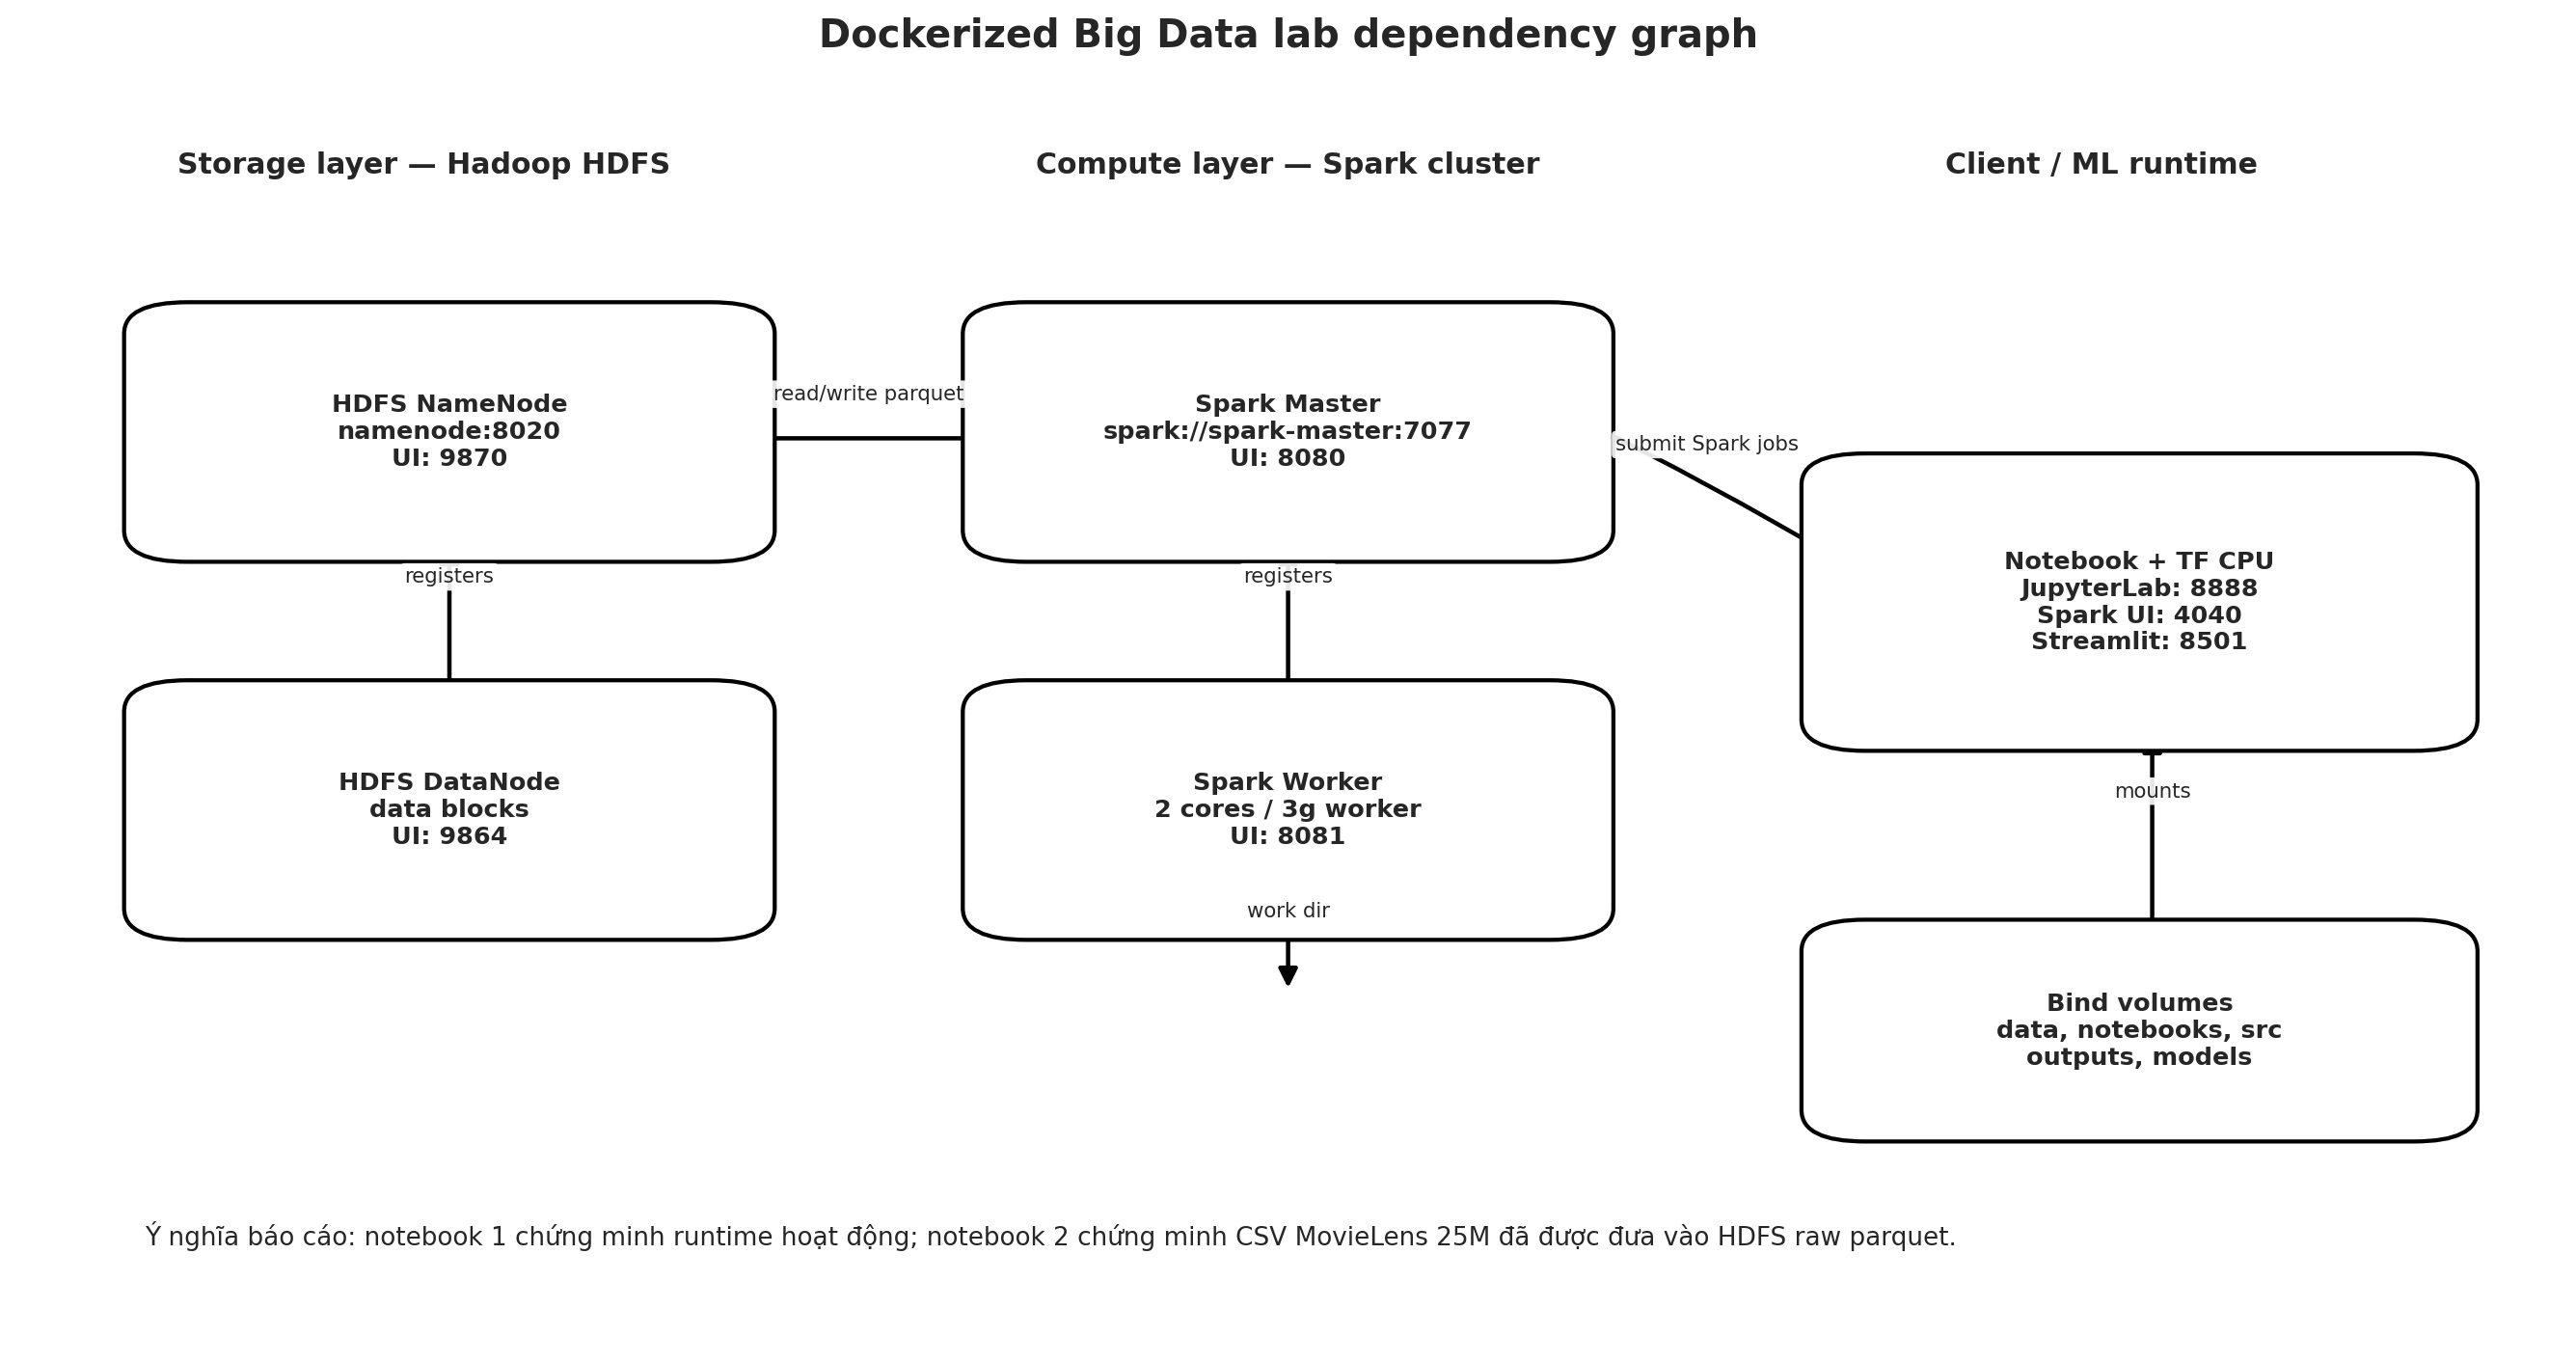

**hdfs_data_lake_lineage** — `hdfs_data_lake_lineage.png`

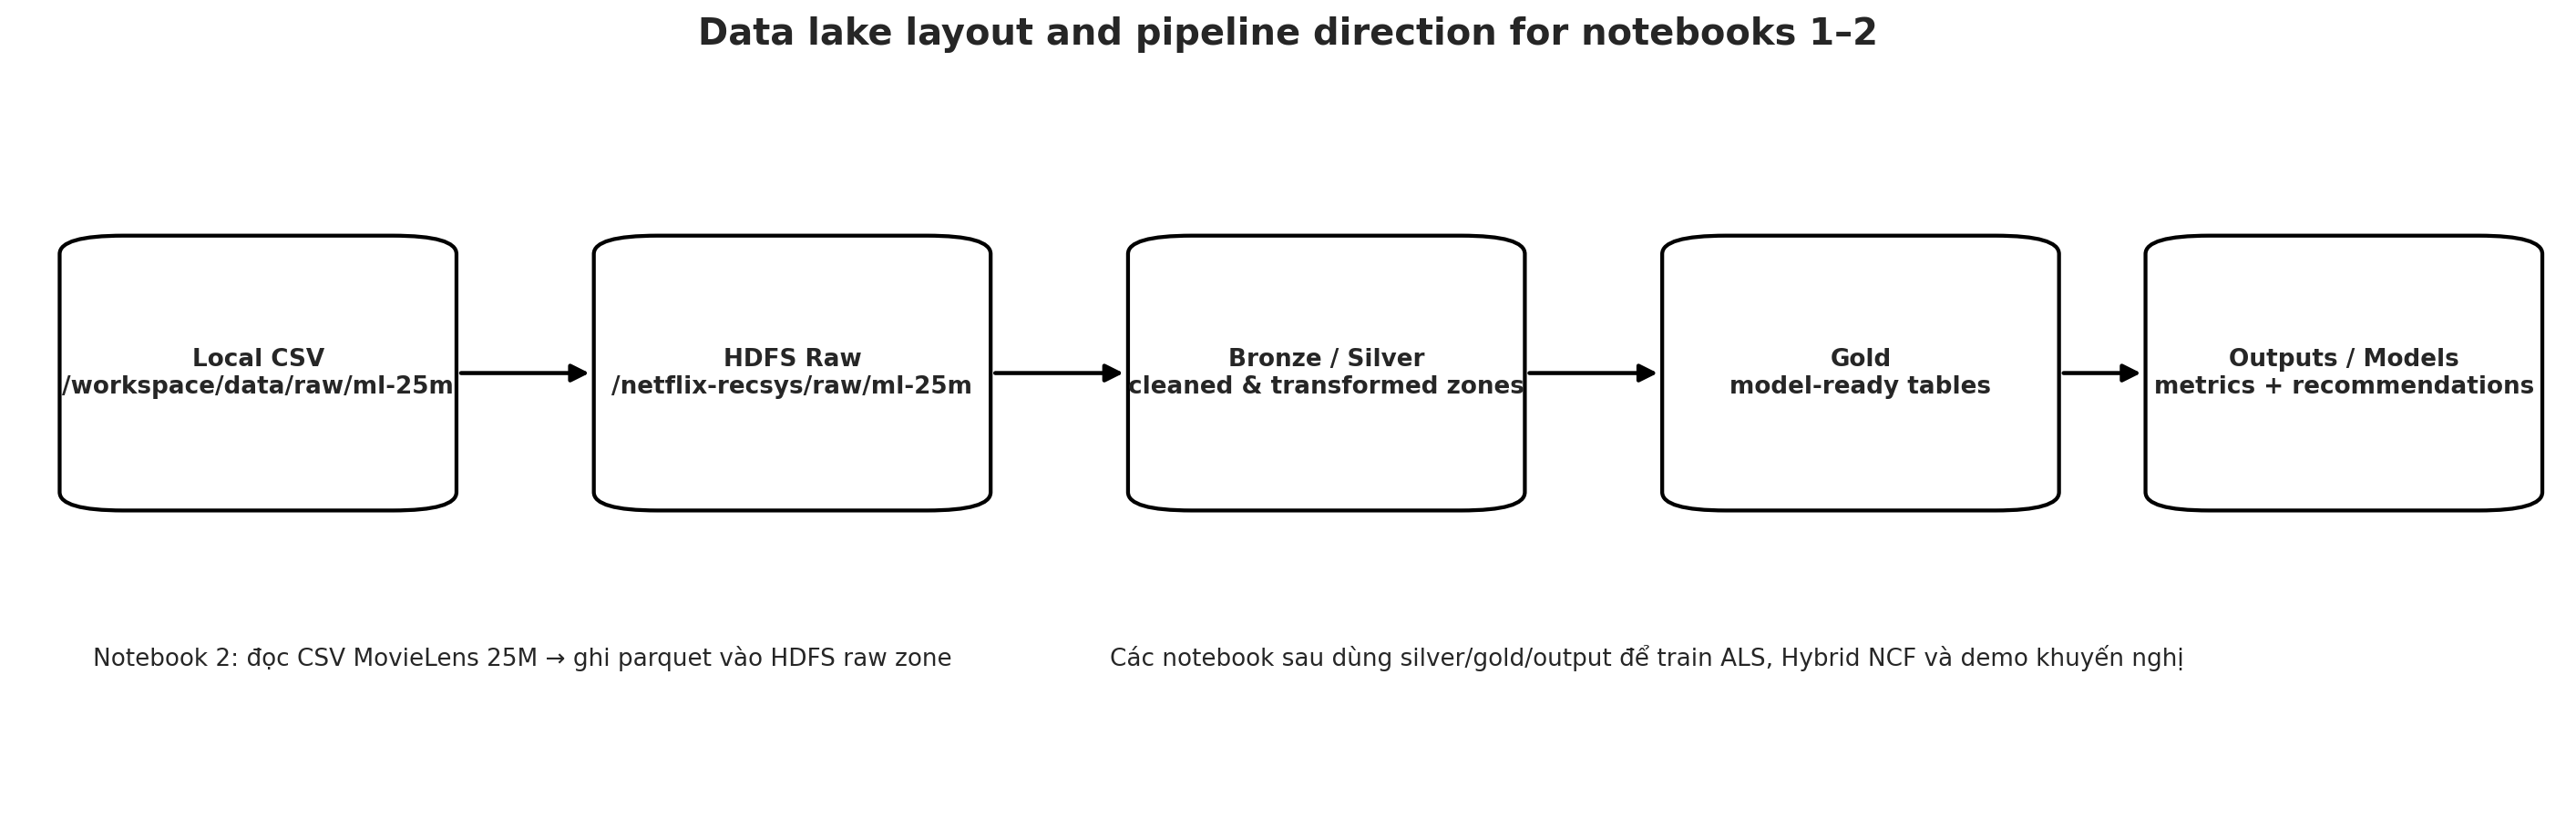

**raw_ingestion_row_counts_logscale** — `raw_ingestion_row_counts_logscale.png`

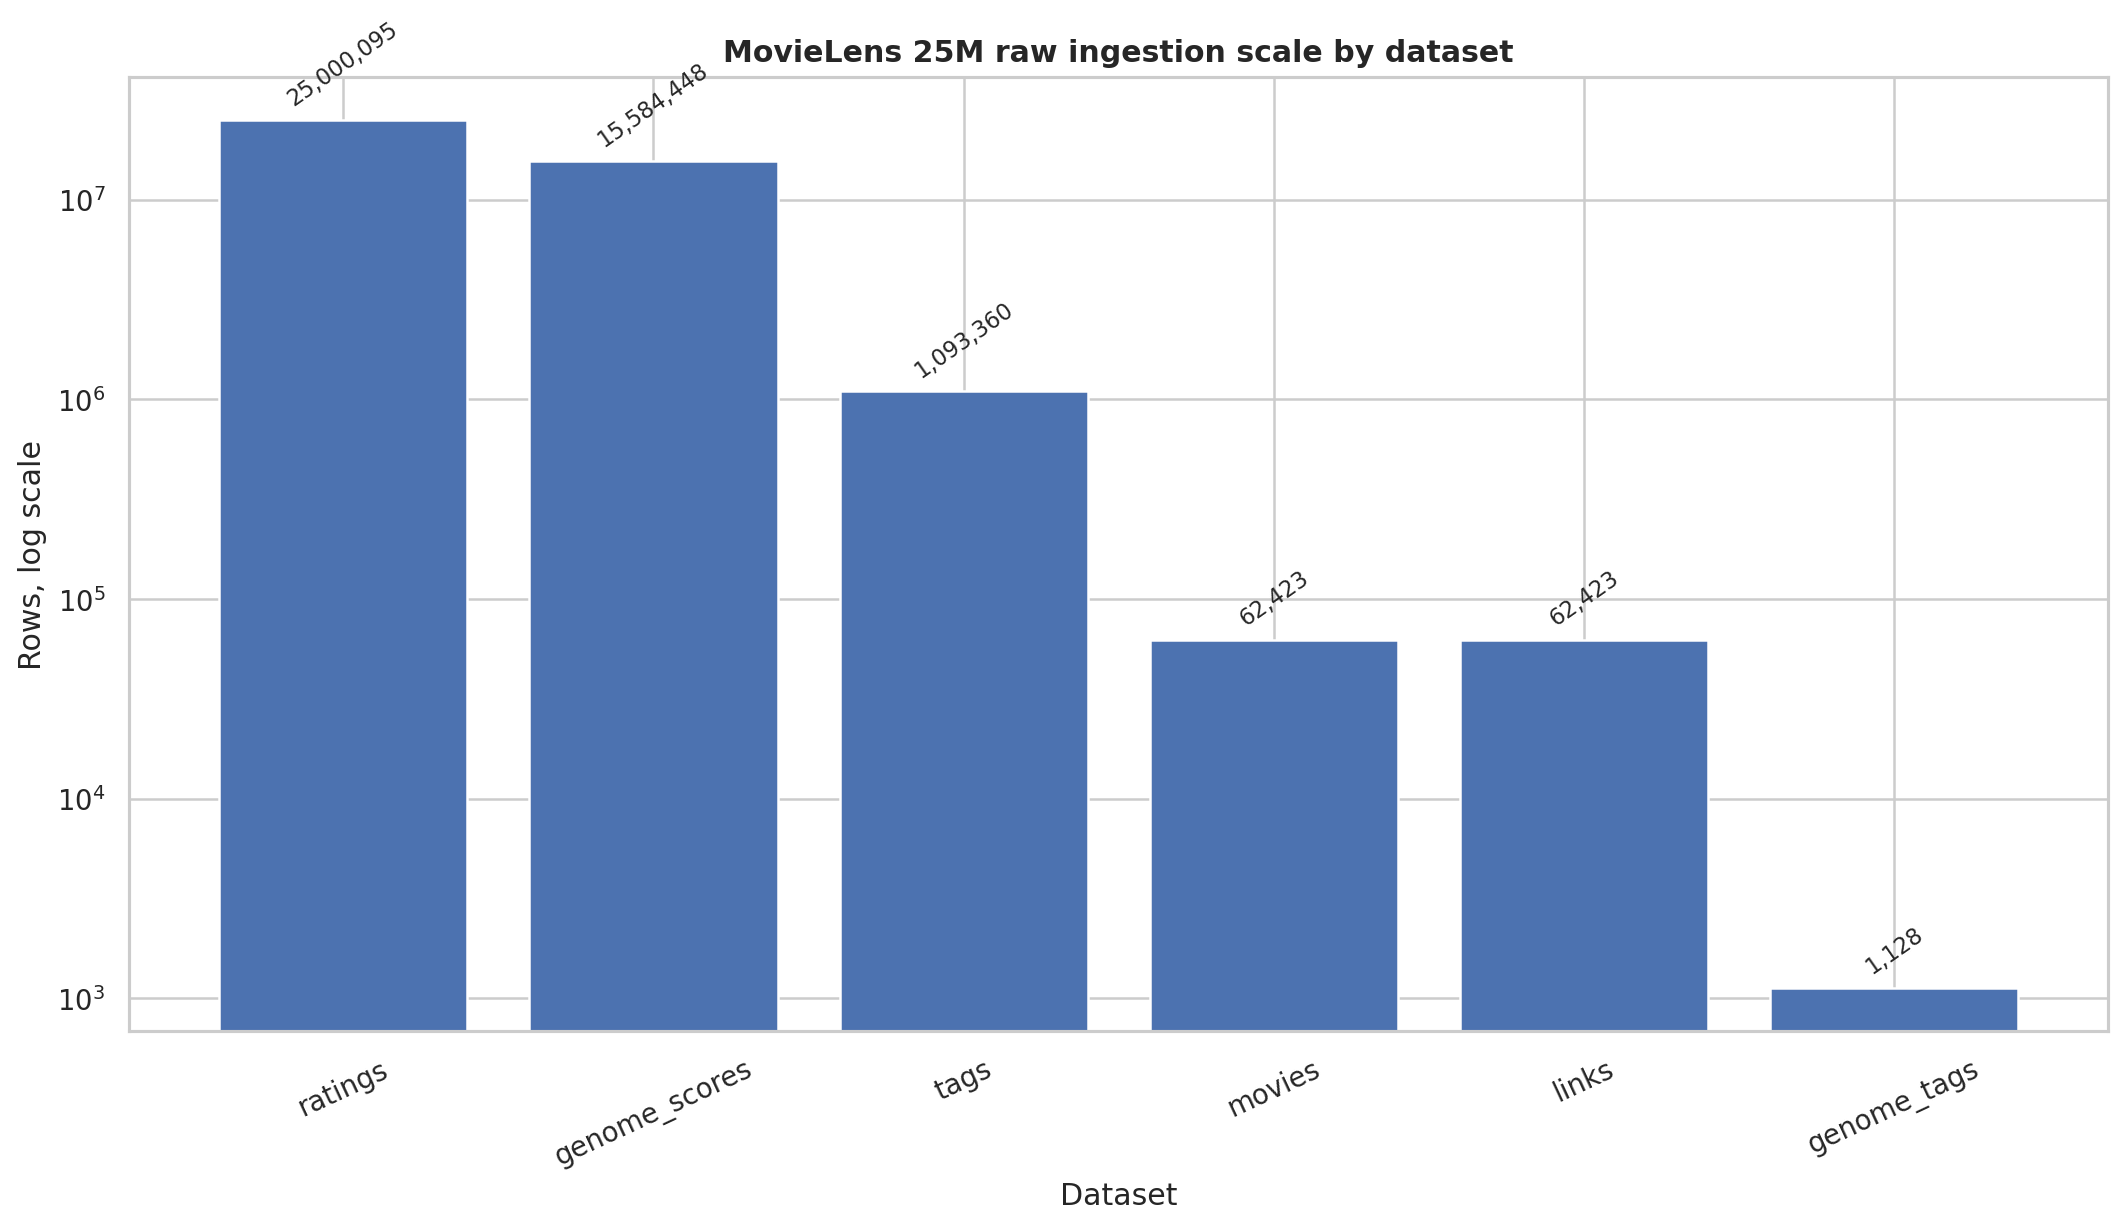

**core_vs_genome_raw_rows** — `core_vs_genome_raw_rows.png`

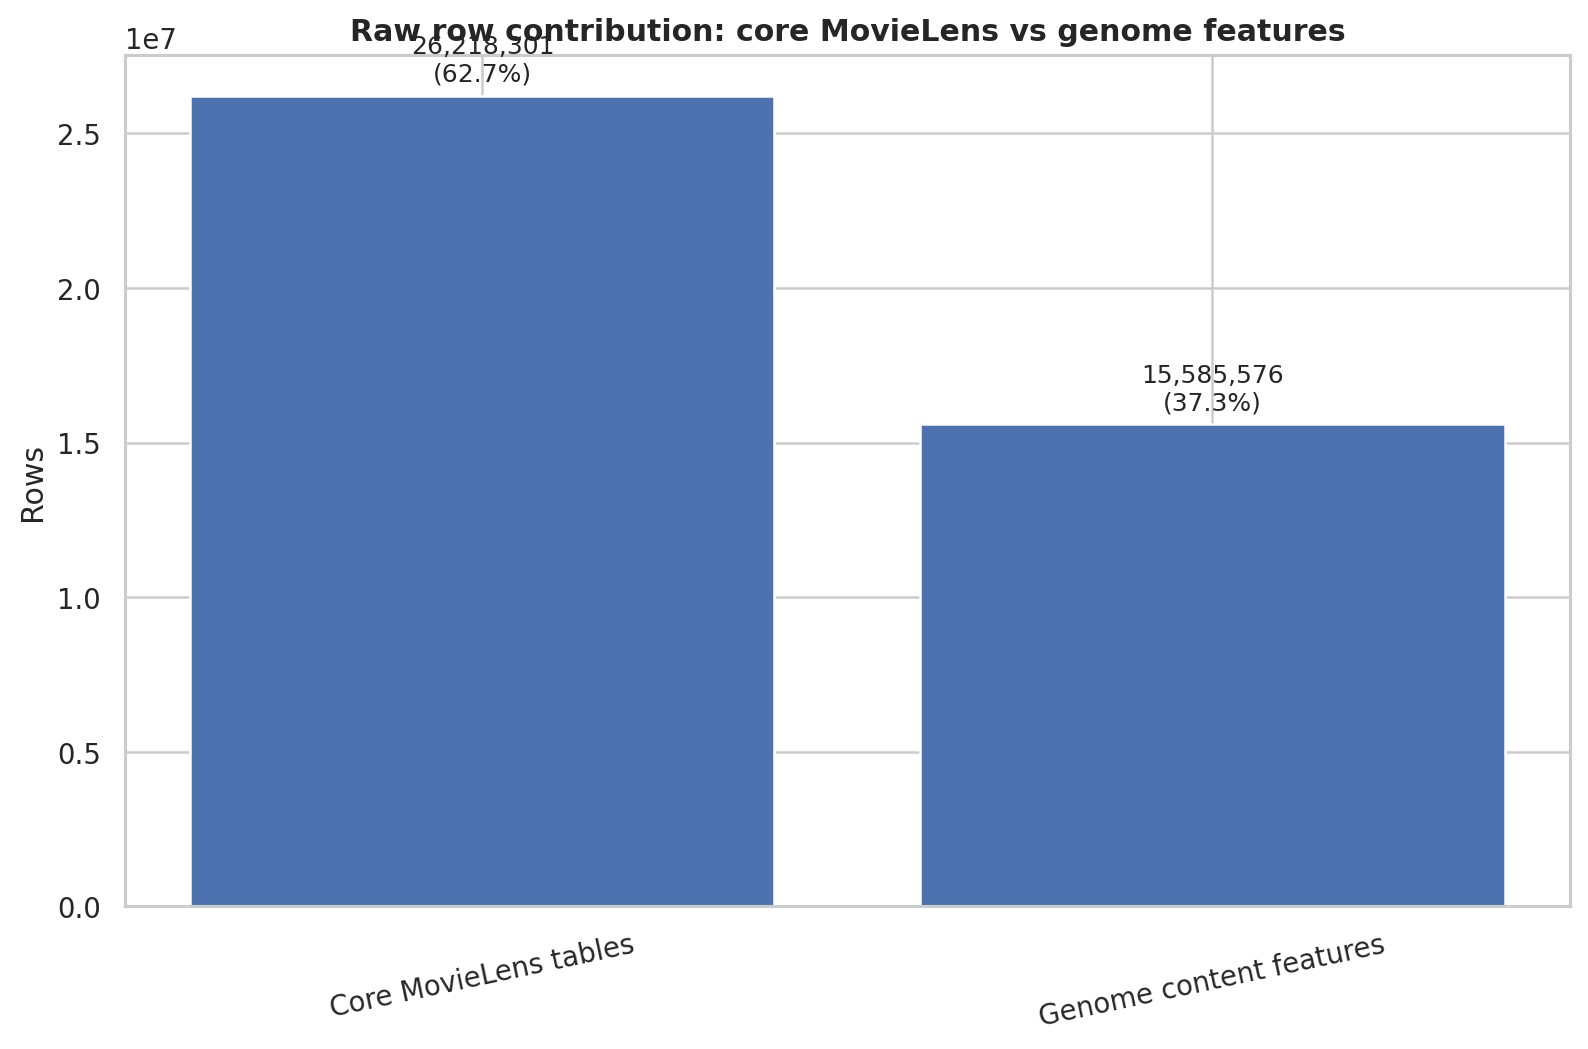

In [13]:
inventory_rows = []
for category, manifest in [
    ("table", exported_tables),
    ("figure", figure_exports),
]:
    for name, path in manifest.items():
        inventory_rows.append({"category": category, "name": name, "path": path})

inventory_df = pd.DataFrame(inventory_rows).sort_values(["category", "name"]).reset_index(drop=True)
save_df(inventory_df, "reporting_asset_inventory")
save_json({"assets": inventory_rows}, METRIC_DIR / "1_2_reporting_asset_inventory.json")

display_df(inventory_df, "Reporting asset inventory")


def preview_figures(keys, width=1050):
    display(Markdown("### Preview: key generated figures"))
    for key in keys:
        path = figure_exports.get(key)
        if not path:
            display(Markdown(f"- `{key}`: not generated"))
            continue
        path = Path(path)
        if not path.exists():
            display(Markdown(f"- `{key}`: file not found at `{path}`"))
            continue
        display(Markdown(f"**{key}** — `{path.name}`"))
        display(Image(filename=str(path), width=width))

preview_figures([
    "docker_service_dependency_graph",
    "hdfs_data_lake_lineage",
    "raw_ingestion_row_counts_logscale",
    "core_vs_genome_raw_rows",
])
